## DeiT-Base model's results on CIFAR-10 dataset using Proposed Mitigation on A40 GPU

### Section 1: Loading Dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
deit_base_data=[]
deit_base_data_test=[]

for i in range(1,101):
    temp1=[]
    for j in range(10):
        path='./mem_csv_deit_base_mod6/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    deit_base_data.append(temp1)

for i in range(1,31):
    temp1=[]
    for j in range(10):
        path='./mem_csv_deit_base_mod6_test/report'+str(j)+'_'+str(i)+'.csv'
        data=pd.read_csv(path)
        temp1.append(data)
    deit_base_data_test.append(temp1)
    temp1=[]
print(deit_base_data[0][1].columns)
print(deit_base_data_test[0][1].columns)

Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__sass_thread_inst_executed_op_fadd_pred_on.sum.per_cycle_elapsed',
       'smsp__sass_thread_inst_executed_op_ffma_pred_on.sum.per_cycle_elapsed',
       'smsp__sass_thread_inst_executed_op_fmul_pred_on.sum.per_cycle_elapsed',
       'smsp__thread_inst_executed_per_inst_executed.ratio',
       'smsp__thread_inst_executed_pred_on_per_inst_executed.ratio',
       'smsp__warps_active.avg.peak_sustained',
       'smsp__warps_active.avg.per_cycle_active',
       'smsp__warps_eligible.avg.per_cycle_active', 'thread_inst_executed',
       'thread_inst_executed_true'],
      dtype='object', length=802)
Index(['ID', 'Process ID', 'Process Name', 'Host Name', 'Kernel Name',
       'Context', 'Stream', 'Block Size', 'Grid Size', 'Device',
       ...
       'smsp__sass_thread_inst_executed_op_fadd_pred_on.sum.per_cycle_elapsed',
       'sms

### Section 2: Pre-processing Dataset

In [3]:
for i in range(100):
    for j in range(10):
        deit_base_data[i][j]=deit_base_data[i][j].drop(['ID'], axis=1)
        if 0 in deit_base_data[i][j].index:
            deit_base_data[i][j] = deit_base_data[i][j].drop(index=0)
        

for i in range(30):
    for j in range(10):
        deit_base_data_test[i][j]=deit_base_data_test[i][j].drop(['ID'], axis=1)
        if 0 in deit_base_data_test[i][j].index:
            deit_base_data_test[i][j] = deit_base_data_test[i][j].drop(index=0)

In [4]:
deit_base_data_test[0][0]['Kernel Name'].unique

<bound method Series.unique of 1     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
2     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
3     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
4     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
5     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
6     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
7     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
8     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
9     fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
10    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
11    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
12    fmha_cutlassF_f32_aligned_64x64_rf_sm80(PyTorc...
Name: Kernel Name, dtype: object>

### Section 3: Metric-based Data filtering and pre-processing

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import random

kernel_name=['fmha_cutlassF_f32_aligned_64x64_rf_sm80']
ltx_cols=[col for col in deit_base_data[0][1].columns if 
    col.startswith('smsp__branch_targets_threads_divergent') #
        or col.startswith('smsp__inst_executed.sum') 
        or col.startswith('smsp__inst_executed_op_branch') 
        or col.startswith('smsp__inst_executed_op_shared_atom') #
        or col.startswith('smsp__sass_inst_executed_op_shared_') 
]
for col in ltx_cols:
    for i in range(100):
        for j in range(10):
           if deit_base_data[i][j][col].dtype == 'object':  # likely string
                deit_base_data[i][j][col] = pd.to_numeric(deit_base_data[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
            
    for i in range(30):
        for j in range(10):
            if deit_base_data_test[i][j][col].dtype == 'object':  # likely string
                deit_base_data_test[i][j][col] = pd.to_numeric(deit_base_data_test[i][j][col].astype(str).str.replace(',', '').str.strip(), errors='coerce')
               
# Optional: update the DataFrame back
print(ltx_cols)

/home/t1000/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


['smsp__branch_targets_threads_divergent', 'smsp__inst_executed.sum', 'smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__sass_inst_executed_op_shared_ld.sum', 'smsp__sass_inst_executed_op_shared_st.sum']


print(len(all_class_data))

In [6]:
deit_base_data[0][0].shape

(12, 801)

### Section 4: Generating classifier model's training data and validation data by considering only the filtered Metrics.

In [7]:
col = [col for col in deit_base_data[0][1].columns if 
        col.startswith('smsp__inst_executed_op_branch') 
        or col.startswith('smsp__inst_executed_op_shared_atom') 
        or col.startswith('smsp__sass_inst_executed_op_shared_') 
]

for i in range(100):
    for j in range(10):
        for c in col:
            deit_base_data[i][j][c]=pd.to_numeric(deit_base_data[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
            
for i in range(30):
    for j in range(10):
        for c in col:
            deit_base_data_test[i][j][c]=pd.to_numeric(deit_base_data_test[i][j][c].astype(str).str.replace(',', '').str.strip(), errors='coerce').astype('float32')
           


# Loop through each DataFrame and keep only the selected columns (if they exist)
deit_base_data_df=[[[] for i in range(10)] for j in range(100)]
deit_base_data_test_df=[[[] for i in range(10)] for j in range(30)]

for i in range(len(deit_base_data)):
    for j in range(len(deit_base_data[i])):
        df2 = deit_base_data[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        deit_base_data_df[i][j] = deit_base_data[i][j][selected_cols].copy()

for i in range(len(deit_base_data_test)):
    for j in range(len(deit_base_data_test[i])):
        df2 = deit_base_data_test[i][j]
        # Keep only the columns that exist in the current DataFrame
        selected_cols = [c for c in col if c in df2.columns]
        deit_base_data_test_df[i][j] = df2[selected_cols].copy()


In [8]:
print(col)

['smsp__inst_executed_op_branch.sum', 'smsp__inst_executed_op_shared_atom.sum', 'smsp__inst_executed_op_shared_atom.sum.pct_of_peak_sustained_elapsed', 'smsp__sass_inst_executed_op_shared_ld.sum', 'smsp__sass_inst_executed_op_shared_st.sum']


In [9]:
deit_base_data_df[0][0].shape

(12, 5)

### Dataset re-arrangement and providing label for training and test samples for both shadow and target model. Also, selecting appropiate range of FMHA kernel instances for achieving maximum attack success rate.

In [38]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train=[]
y_train=[]
X_test=[]
y_test=[]

for i in range(100):
    for j in range(10):
        r = deit_base_data_df[i][j]  # shape: (12, 2)
        X_train.append(r)

        if i < 50:
            y_train.append(1)
        else:
            y_train.append(0)

for i in range(30):
    for j in range(10):
        r = deit_base_data_test_df[i][j]  # shape: (12, 2)
        X_test.append(r)

        if i < 15:
            y_test.append(1)
        else:
            y_test.append(0)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

X_train = X_train[:, 0:8, :]
X_test = X_test[:, 0:8, :]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1000, 8, 5) (1000,)
(300, 8, 5) (300,)


In [39]:
import numpy as np
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([500, 500]))
(array([0, 1]), array([150, 150]))


In [40]:
from tensorflow.keras.utils import to_categorical

### Attack Classifier training

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
import numpy as np
from sklearn.model_selection import train_test_split

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  
def reset_random_seeds():
   os.environ['PYTHONHASHSEED']=str(42)
   tf.random.set_seed(42)
   np.random.seed(42)
   random.seed(42)

reset_random_seeds()
import tensorflow as tf

# Your input data shape: (samples, sequence_length, feature_dim)
num_samples = X_train.shape[0]
sequence_length = X_train.shape[1]
feature_dim = X_train.shape[2]

# Define the model
# Stacked BiLSTM Layers
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(sequence_length, feature_dim)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(32, return_sequences=False)))
model.add(Dropout(0.2))

# Fully connected hidden layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))


# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
X_train = (X_train - mean) / (std + 1e-8)
# Summary
model.summary()
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)
# Train
history = model.fit(
    X_train_split, y_train_split,
    epochs=90,
    batch_size=45,
    validation_data=(X_val_split, y_val_split)
)

/home/t1000/.local/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_8 (Bidirectional) │ (None, 8, 128)         │        35,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 8, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,281 (317.50 KB)

 Trainable params: 81,281 (317.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5025 - loss: 0.6928 - val_accuracy: 0.5250 - val_loss: 0.6922
Epoch 2/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5188 - loss: 0.6927 - val_accuracy: 0.5050 - val_loss: 0.6919
Epoch 3/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5475 - loss: 0.6884 - val_accuracy: 0.4950 - val_loss: 0.6906
Epoch 4/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5512 - loss: 0.6876 - val_accuracy: 0.5250 - val_loss: 0.6868
Epoch 5/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5913 - loss: 0.6809 - val_accuracy: 0.5650 - val_loss: 0.6794
Epoch 6/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5863 - loss: 0.6740 - val_accuracy: 0.5700 - val_loss: 0.6750
Epoch 7/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5813 - loss: 0.6707 - val_accuracy: 0.6050 - val_loss: 0.6710
Epoch 8/90
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5788 - loss: 0.6707 - val_accuracy: 0.6100 - val_loss

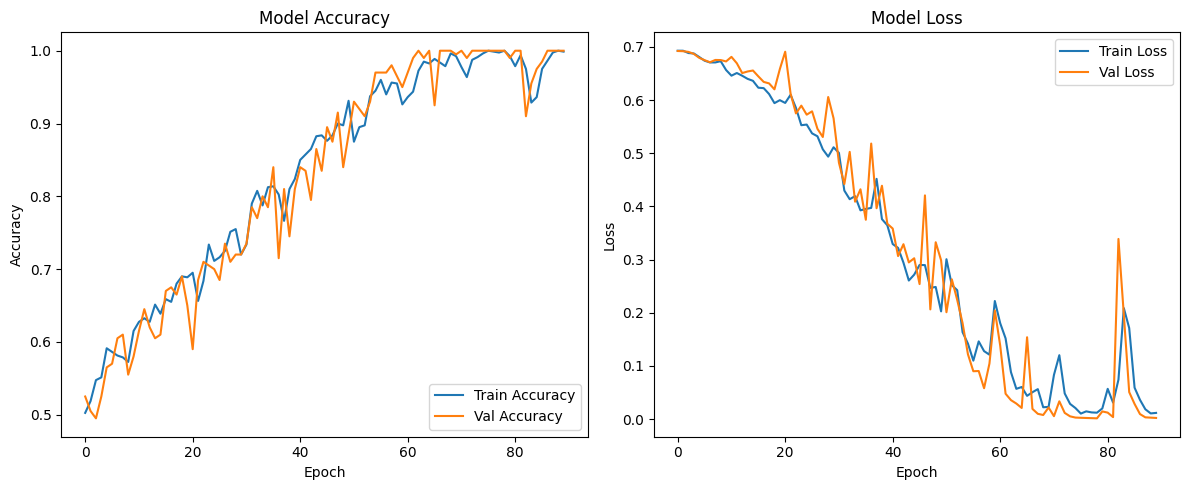

In [42]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


### Membership Inference Attack on Target Model Data

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Test Accuracy: 0.7033
Confusion Matrix:
 [[102  48]
 [ 41 109]]


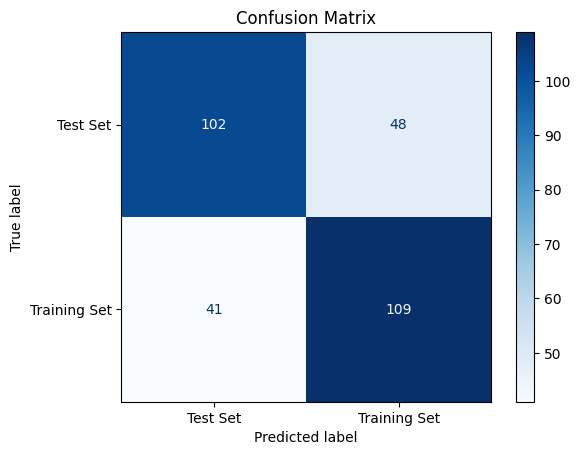

In [43]:
# Predict
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

mean = X_test.mean(axis=(0, 1), keepdims=True)
std = X_test.std(axis=(0, 1), keepdims=True)
X_test = (X_test - mean) / (std + 1e-8)

# Predict probabilities
predictions = model.predict(X_test)

# # Convert probabilities to binary labels
predicted_labels = (predictions > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, predicted_labels)
print(f"Test Accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)
print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Test Set", "Training Set"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()



F1 Score: 0.7101
AUC Score: 0.7613


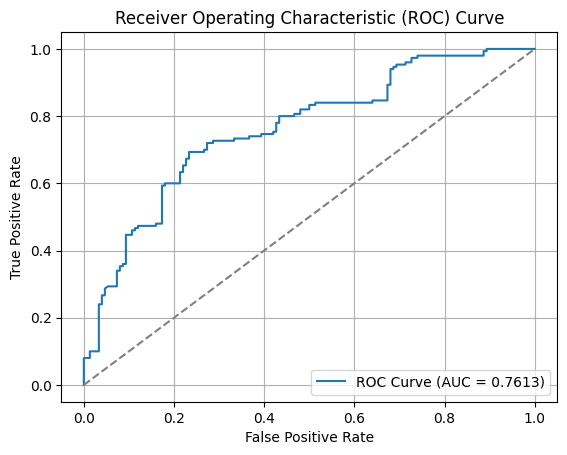

In [44]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Binary predictions using threshold 0.5
predicted_labels = (predictions >= 0.5).astype(int)

# F1 Score
f1 = f1_score(y_test, predicted_labels)
print(f"F1 Score: {f1:.4f}")

# AUC Score
auc_score = roc_auc_score(y_test, predictions)
print(f"AUC Score: {auc_score:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Random chance line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
